I decided to use Wages by education level data from Ontario, sourced at (https://data.ontario.ca/dataset/wages-by-education-level) and produce visualization using python.

Important characteristics (from contextual documentation):

>Information on wages by education level and immigration status for Canada and Ontario.

>Source: Statistics Canada, Labour Force Survey Special Tabulations (CANSIM Table 282-0004). Reproduced and distributed on an "as is" basis with the permission of Statistics Canada (Statistics Canada Open Licence Agreement). 

>Estimates in thousands, rounded to the nearest hundred.

>Wage rate in Canadian dollars per week.

I downloaded a csv file containing data, so I will begin by reading it into a data frame df, the I will produce visualization. The assignment answers are here; code is below. As per request of the instructor I have replicated the images only on a separate file called assignment-3-trends.png

> What software did you use to create your data visualization?

I used visual studio code and python language.

> Who is your intended audience? 

Labour Economics students, or any people trying to understand how wage varies based on education and gender.
    
> What information or message are you trying to convey with your visualization? 

I intend to show how the gender pay gap remains somewhat stable overtime. However, contrarily to my expectations (based on the human capital model), I also show that it is higher than the average when I selected only people with Bachelor degrees.

> What aspects of design did you consider when making your visualization? How did you apply them? With what elements of your plots? 

The data points connected by a lines that seem to grow more or less smoothly help visualize that there is a trend (wages grew over time), and that despite the fact tha both grew, the male line is consistently above the female line. In the final plot, I also wanted to show simulateneously how more educated people (Bachelor's degree) consistently make more money than the average population, but females are still below males. In addition, the unexpected finding the date indicated is that the gap (distance between lines) is slightly larger for people holding Bachelor's degrees than the average gap. 
I believe using high contrast colors and different line styles helps the observer understand the graph. I strugled with the width of the lines - typically a thicker line should be easier to view, but after testing, I noticed thinner ones were doing a better job. Unfortunately I could not find a simple way to selected the style of the lines. I managed to split the legend into 2 columns (using code we learned) to help the aesthetics of the graph.
    
> How did you ensure that your data visualizations are reproducible? If the tool you used to make your data visualization is not reproducible, how will this impact your data visualization? 

The data I used is public; I am not too concern about exact values because the important element here is the trend. So even if someone used a slighly different sample from puclicly available data in Ontario, similar results should be found.


> How did you ensure that your data visualization is accessible? 

I did not worry much about the 2 separate plots, but for the final visualization, where I gathered all the data I wanted to show, I made sure the titles were large, as well as the names of the axes; I used a more simple title, but put the legend box up, so the information is displayed from top to bottom, and I used strong colors, in high constrast. Male is consistently above Female lines, so even for color blind obersvers it should be possible to see, although the visualization would not be as clear. I wish I could make the line designs more distinct. Finally, on the X axis I included the information about the years (from 1997 to 2016) so someone who has issues with reading small letters would know what the marks on the horizontal axis stand for.

    
> Who are the individuals and communities who might be impacted by your visualization?  

First, I would say both men and women, but in different ways. Women may be angry, and men may finally understand that the wage gap is real. However, it could also negativelly afect non-binary people, or people who don't identity as either male or female. This dataset, like many others, over emphasizes the assumed binary nature of sex and gender by invisibilizing respondents who identify with neither option. This answer is the same for both the histogram and the trend plot.

> How did you choose which features of your chosen dataset to include or exclude from your visualization? 

I chose to plot average wages over time, and to show the values for Male and Female on the same graph so people could see both values grow, but Males are always on top. then, I chose to filter full-time workers with bachelor's degrees only to clarify that the gap still exists, even when controling for level of education. It would be interesting to see a filter by occupation as well, but it was not available in the chosen dataset.
    
> What ‘underwater labour’ contributed to your final data visualization product?

Assuming this is what you mean by "underwater labour", I had to manually figure out the exact names of each column header and the values I was filtering, or the code would not run. I could have tried removing these elements from the entire dataset, but that seemed more complicated short-term. I tried different colors and font sizes until I found the ones I chose. I think the most important work was looking into the csv file to find that information, instead of just working inside the python code, because the names of the columns and types of value "options" were not very obvious just from the first few rows (e.g., the column "Wages" does not correspont to the actual wage rates; but also it wasn't clear from the .head() function that there were rows for combined values besides of the unique values for many of the columns)

In [4]:
# Libraries (I started with the libraries used in class, 
# then added other required ones along the way)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mticker
import seaborn as sns

In [5]:
# reading data that is on the same folder as my code file :)
df = pd.read_csv("114 Wages of employees UTF-8.csv")
print(df.head())

   Year Geography              Type of work              Education level  \
0  1997    Canada  Both full- and part-time  Total, all education levels   
1  1998    Canada  Both full- and part-time  Total, all education levels   
2  1999    Canada  Both full- and part-time  Total, all education levels   
3  2000    Canada  Both full- and part-time  Total, all education levels   
4  2001    Canada  Both full- and part-time  Total, all education levels   

      Sex           Age group            Wages   Value  
0    Male  15 years and over   Total employees  5954.5  
1    Male  15 years and over   Total employees  6060.1  
2    Male  15 years and over   Total employees  6203.8  
3    Male  15 years and over   Total employees  6427.6  
4    Male  15 years and over   Total employees  6520.2  


In [6]:
# Filtering the data I need
# I used Copilot to help me use filters in python, 
# then added my own corrections (e.g., added spaces manually)
mask = (
    (df["Geography"] == "Ontario") &
    (df["Type of work"] == "Both full- and part-time") &
    (df["Education level"] == "Total, all education levels") &
    (df["Age group"] == "15 years and over ") &
    (df["Wages"] == "Average hourly wage rate")
)

filtered = df[mask].copy()
print(filtered.head())

        Year Geography              Type of work              Education level  \
349440  1997   Ontario  Both full- and part-time  Total, all education levels   
349441  1998   Ontario  Both full- and part-time  Total, all education levels   
349442  1999   Ontario  Both full- and part-time  Total, all education levels   
349443  2000   Ontario  Both full- and part-time  Total, all education levels   
349444  2001   Ontario  Both full- and part-time  Total, all education levels   

           Sex           Age group                     Wages  Value  
349440    Male  15 years and over   Average hourly wage rate  17.87  
349441    Male  15 years and over   Average hourly wage rate  18.10  
349442    Male  15 years and over   Average hourly wage rate  18.74  
349443    Male  15 years and over   Average hourly wage rate  19.43  
349444    Male  15 years and over   Average hourly wage rate  20.15  


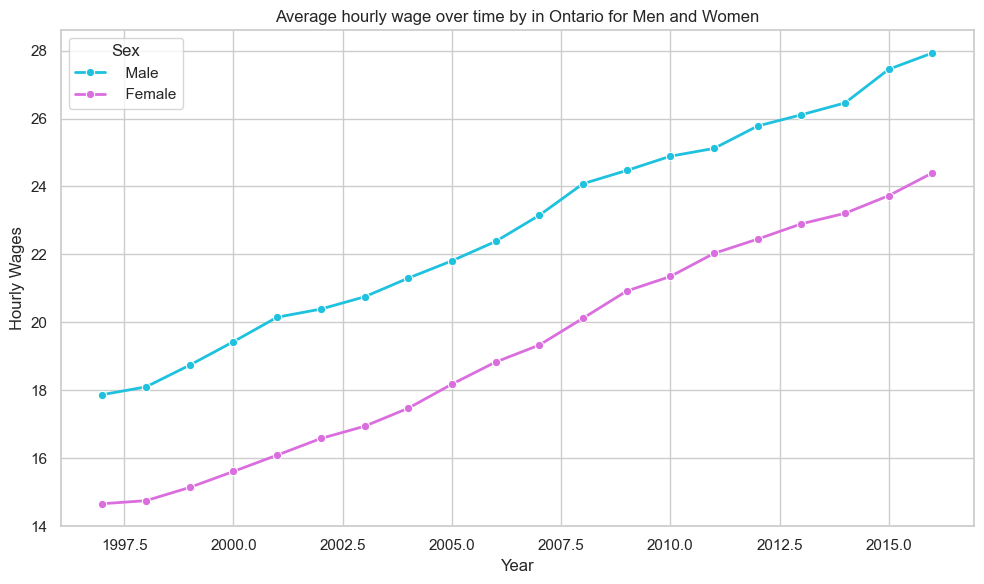

In [7]:
# relevant libraries for the plot (imported above)
#import pandas as pd
#import seaborn as sns
#import matplotlib.pyplot as plt

palette = {
    "  Male":   "#1ec1de",  # light blue
    "  Female": "#da6ede",  # light pink
}

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=filtered, 
    x="Year", 
    y="Value", 
    hue="Sex", 
    palette=palette,
    marker="o", 
    linewidth=2)
plt.title("Average hourly wage over time by in Ontario for Men and Women")
plt.xlabel("Year")
plt.ylabel("Hourly Wages")
plt.tight_layout()
plt.show()

In [8]:
# Filtering the data I need - second round

mask = (
    (df["Geography"] == "Ontario") &
    (df["Type of work"] == "   Full-time ") &
    (df["Education level"] == "      Bachelor's degree") &
    (df["Age group"] == "15 years and over ") &
    (df["Wages"] == "Average hourly wage rate")
)

filteredEd = df[mask].copy()
print(filteredEd.head())

        Year Geography   Type of work          Education level     Sex  \
371840  1997   Ontario     Full-time         Bachelor's degree    Male   
371841  1998   Ontario     Full-time         Bachelor's degree    Male   
371842  1999   Ontario     Full-time         Bachelor's degree    Male   
371843  2000   Ontario     Full-time         Bachelor's degree    Male   
371844  2001   Ontario     Full-time         Bachelor's degree    Male   

                 Age group                     Wages  Value  
371840  15 years and over   Average hourly wage rate  23.55  
371841  15 years and over   Average hourly wage rate  22.98  
371842  15 years and over   Average hourly wage rate  24.40  
371843  15 years and over   Average hourly wage rate  25.49  
371844  15 years and over   Average hourly wage rate  26.21  


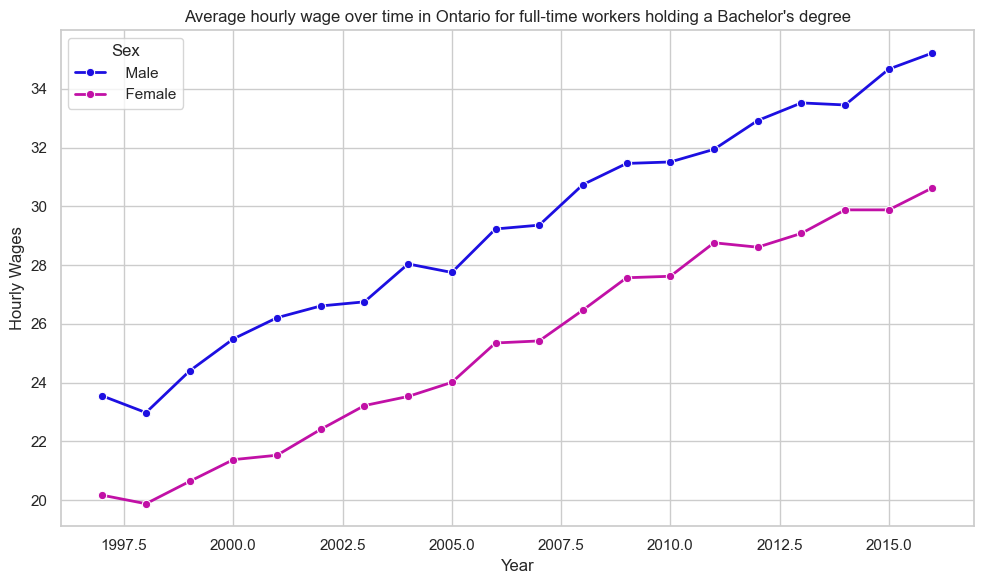

In [9]:
# Visualizing only people with the same educational level

palette = {
    "  Male":   "#1d0fe1",  # blue
    "  Female": "#c110a6",  # pink
}

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=filteredEd, 
    x="Year", 
    y="Value", 
    hue="Sex", 
    palette=palette,
    marker="o", 
    linewidth=2)
plt.title("Average hourly wage over time in Ontario for full-time workers holding a Bachelor's degree")
plt.xlabel("Year")
plt.ylabel("Hourly Wages")
plt.tight_layout()
plt.show()

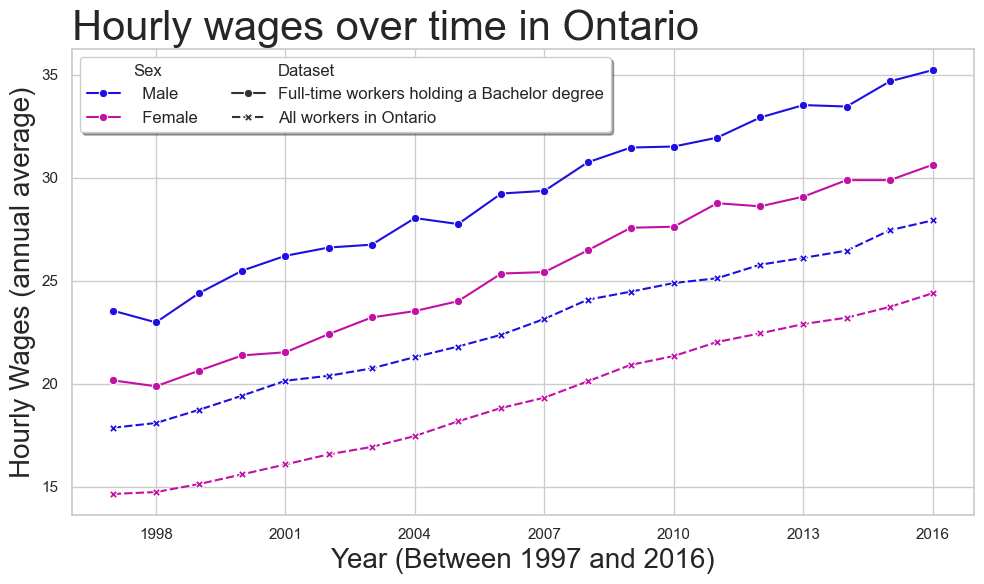

In [10]:
# Plotting (on the same graph) both trends

# Step 1 - -Add a label to each DataFrame
b = filtered.copy()
b["Dataset"] = "All workers in Ontario"      # rename as you like

a = filteredEd.copy()
a["Dataset"] = "Full-time workers holding a Bachelor degree"      # rename as you like

# Step 2 - Stack them
both = pd.concat([a, b], ignore_index=True)

# Step 3 - Plot: colors = Sex; line styles = distinguished by Dataset

palette = {
    "  Male":   "#1d0fe1",  # blue
    "  Female": "#c110a6",  # pink
}

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=both,
    x="Year", 
    y="Value",
    palette=palette,
    marker="o",
    hue="Sex",              # Male/Female -> colors
    style="Dataset",        # Dataset -> line style
    markers=True, 
    dashes=True, 
    linewidth=1.5           # Tested several, think this is clearer
)
ax = plt.gca()
#import matplotlib.ticker as mticker
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax.legend(loc='upper left',
        frameon = True, #add frame around the legend
        fontsize = 12, #change font size
        ncol = 2, #specify number of columns
        shadow = True )

plt.title("Hourly wages over time in Ontario", size=30, loc="left")
plt.xlabel("Year (Between 1997 and 2016)", size=20)
plt.ylabel("Hourly Wages (annual average)", size=20)
#plt.legend(loc="lower right")
plt.tight_layout()
plt.show()



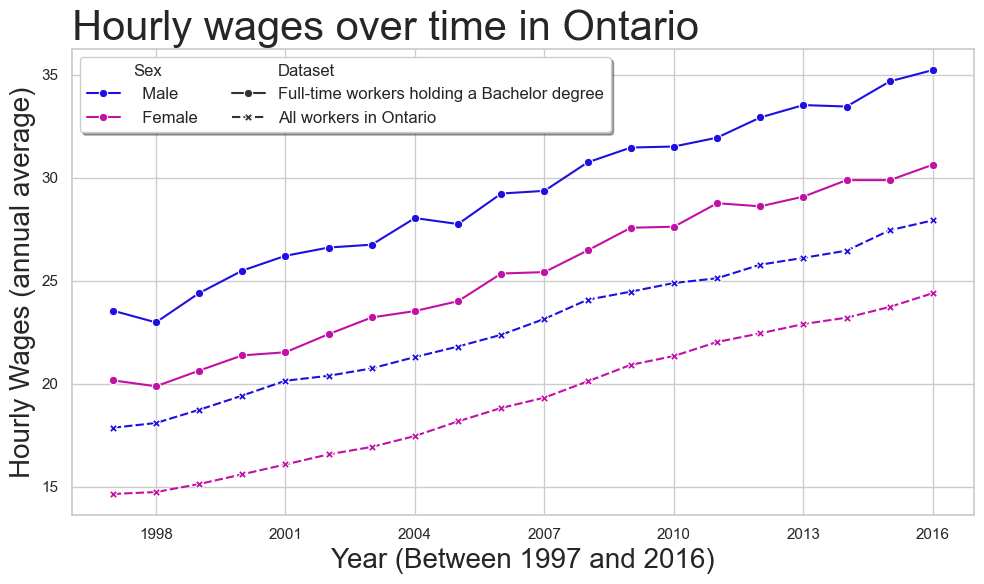

In [14]:
# Saving into an image file

# Step 1 - -Add a label to each DataFrame
b = filtered.copy()
b["Dataset"] = "All workers in Ontario"      # rename as you like

a = filteredEd.copy()
a["Dataset"] = "Full-time workers holding a Bachelor degree"      # rename as you like

# Step 2 - Stack them
both = pd.concat([a, b], ignore_index=True)

# Step 3 - Plot: colors = Sex; line styles = distinguished by Dataset

palette = {
    "  Male":   "#1d0fe1",  # blue
    "  Female": "#c110a6",  # pink
}

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=both,
    x="Year", 
    y="Value",
    palette=palette,
    marker="o",
    hue="Sex",              # Male/Female -> colors
    style="Dataset",        # Dataset -> line style
    markers=True, 
    dashes=True, 
    linewidth=1.5           # Tested several, think this is clearer
)
ax = plt.gca()
#import matplotlib.ticker as mticker
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

ax.legend(loc='upper left',
        frameon = True, #add frame around the legend
        fontsize = 12, #change font size
        ncol = 2, #specify number of columns
        shadow = True )

plt.title("Hourly wages over time in Ontario", size=30, loc="left")
plt.xlabel("Year (Between 1997 and 2016)", size=20)
plt.ylabel("Hourly Wages (annual average)", size=20)
#plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("C:/Users/anade/OneDrive/Área de Trabalho/visualization/02_activities/assignments/assignment-3-trends", dpi=300)


